In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/creditcard.csv")

df_processed = df.copy()

print("Dataset shape:", df_processed.shape)

Dataset shape: (284807, 31)


In [5]:
duplicate_count = df_processed.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 1081


In [6]:
missing_values = df_processed.isnull().sum()

print("Total missing values:", missing_values.sum())

Total missing values: 0


In [7]:
print(df_processed["Class"].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [8]:
# Missing Value Analysis

# The dataset contains no missing values across any of its columns.

# Therefore, no missing-value imputation or row removal is required during
# preprocessing.

In [9]:
duplicate_count = df_processed.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 1081


In [10]:
# Duplicate Row Analysis

# The dataset contains 1,081 exact duplicate rows.

# Since these rows contain identical values across all columns, keeping them
# would give repeated observations additional influence during model training.

# The duplicate rows will therefore be removed before model development.

In [11]:
df_processed["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [12]:
df_processed = df_processed.drop_duplicates().copy()

print("Shape after removing duplicates:", df_processed.shape)

Shape after removing duplicates: (283726, 31)


In [13]:
df_processed["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [14]:
fraud = (df_processed["Class"] == 1).sum()
total = len(df_processed)

print("Fraudulent transactions:", fraud)
print("Total transactions:", total)
print("Fraud percentage:", round((fraud / total) * 100, 4), "%")

Fraudulent transactions: 473
Total transactions: 283726
Fraud percentage: 0.1667 %


In [15]:
# Duplicate Removal Results

# The original dataset contained 1,081 exact duplicate rows.

# After removing duplicates:

# - Total transactions: 283,726
# - Fraudulent transactions: 473
# - Fraud rate: 0.1667%

# The duplicate removal slightly reduced the number of fraudulent examples,
# so the severe class imbalance remains an important consideration for model
# development.

In [16]:
X = df_processed.drop(columns=["Class"])
y = df_processed["Class"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (283726, 30)
Target shape: (283726,)


In [17]:
print("Features:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

Features:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']

Target distribution:
Class
0    283253
1       473
Name: count, dtype: int64


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 226980
Testing samples: 56746

Training class distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Testing class distribution:
Class
0    56651
1       95
Name: count, dtype: int64


In [20]:
print(
    "Training fraud rate:",
    round(y_train.mean() * 100, 4),
    "%"
)

print(
    "Testing fraud rate:",
    round(y_test.mean() * 100, 4),
    "%"
)

Training fraud rate: 0.1665 %
Testing fraud rate: 0.1674 %


In [21]:
# Stratified Train-Test Split

# The processed dataset was divided into training and testing sets using an
# 80:20 split.

# Stratification was applied using the target variable `Class` so that the
# severely imbalanced fraud distribution was preserved in both subsets.

# The resulting fraud rates are:

# - Training set: 0.1665%
# - Testing set: 0.1674%

# The similar proportions confirm that the class distribution was preserved
# during the split.

In [22]:
print(X_train[["Time", "Amount"]].describe())

                Time         Amount
count  226980.000000  226980.000000
mean    94900.224390      88.387124
std     47488.214282     245.767046
min         0.000000       0.000000
25%     54241.750000       5.690000
50%     84816.000000      22.080000
75%    139364.250000      77.850000
max    172792.000000   19656.530000


In [23]:
print("Time range:")
print(X_train["Time"].min(), "to", X_train["Time"].max())

print("\nAmount range:")
print(X_train["Amount"].min(), "to", X_train["Amount"].max())

Time range:
0.0 to 172792.0

Amount range:
0.0 to 19656.53


In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

numeric_features = X_train.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features)
    ]
)

print("Number of features to scale:", len(numeric_features))

Number of features to scale: 30


In [25]:
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

Training shape: (226980, 30)
Testing shape: (56746, 30)


In [26]:
preprocessor.fit_transform(X_train)

array([[ 1.04549909,  1.14719836, -1.04203246, ...,  0.09278213,
        -0.15619266, -0.22943372],
       [-0.29869002, -0.67791131,  0.99194846, ..., -0.04986389,
         0.15383143, -0.33119698],
       [ 0.67839667,  0.97765362,  0.0162054 , ...,  0.11132947,
        -0.16581986, -0.29880852],
       ...,
       [ 1.19385202, -0.45214212,  0.70655379, ..., -0.62638332,
         0.28835592, -0.20908921],
       [-0.95824459,  0.63781446,  0.21468286, ...,  0.10812079,
         0.09533138, -0.3392941 ],
       [-0.89610272,  0.52361687, -0.13216317, ...,  0.1416972 ,
        -0.0070969 , -0.30955042]], shape=(226980, 30))

In [27]:
preprocessor.transform(X_test)

array([[-0.70776084,  0.62846035, -0.03507436, ...,  0.00334824,
         0.00256256, -0.31284623],
       [ 1.27387205, -0.10690835,  0.71666883, ...,  0.96769184,
         0.79940005, -0.35174494],
       [-1.34811061, -0.86164079,  0.85283366, ...,  0.01560762,
         0.34674777,  0.01177083],
       ...,
       [-0.44196799,  0.60372332, -0.11740337, ...,  0.02988069,
         0.07761042, -0.32244884],
       [ 0.68907303,  1.05584343,  0.08623043, ..., -0.16707329,
        -0.13668677, -0.35601729],
       [-1.76535189,  0.63786439,  0.04036693, ..., -0.21956371,
         0.02075116, -0.29473961]], shape=(56746, 30))

In [28]:
print("Training mean:", X_train_scaled.mean())
print("Training standard deviation:", X_train_scaled.std())

Training mean: -3.48937484709633e-18
Training standard deviation: 1.0


In [29]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

print(logistic_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Time', 'V1', 'V2', 'V3',
                                                   'V4', 'V5', 'V6', 'V7', 'V8',
                                                   'V9', 'V10', 'V11', 'V12',
                                                   'V13', 'V14', 'V15', 'V16',
                                                   'V17', 'V18', 'V19', 'V20',
                                                   'V21', 'V22', 'V23', 'V24',
                                                   'V25', 'V26', 'V27', 'V28',
                                                   'Amount'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])


In [30]:
X_train_transformed = logistic_pipeline.named_steps["preprocessor"].fit_transform(X_train)

X_test_transformed = logistic_pipeline.named_steps["preprocessor"].transform(X_test)

print("Transformed training shape:", X_train_transformed.shape)
print("Transformed testing shape:", X_test_transformed.shape)

Transformed training shape: (226980, 30)
Transformed testing shape: (56746, 30)


## Preprocessing Pipeline

The dataset was split into training and testing sets using stratification.

All numerical features are standardized using `StandardScaler`. The scaler
is fitted only on the training data and then applied to the testing data.

A scikit-learn `Pipeline` is used so that preprocessing and model prediction
can be performed consistently as a single workflow.

This approach also helps prevent data leakage when the model is evaluated or
used for predictions on new transactions.

In [31]:
logistic_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['Time','V1','V2',...,'V27','V28','Amount']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified i

In [32]:
y_pred = logistic_pipeline.predict(X_test)
y_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("PR-AUC   :", average_precision_score(y_test, y_prob))

Accuracy : 0.9753110351390406
Precision: 0.05638586956521739
Recall   : 0.8736842105263158
F1 Score : 0.10593490746649649
ROC-AUC  : 0.9656548079701293
PR-AUC   : 0.6719244530518994


## Baseline Model: Logistic Regression

Logistic Regression was trained as the first baseline model using
standardized features and balanced class weights.

The model achieved:

- Accuracy: 97.53%
- Precision: 5.64%
- Recall: 87.37%
- F1 Score: 10.59%
- ROC-AUC: 96.57%
- PR-AUC: 67.19%

Although the accuracy is high, it is not sufficient as the primary
evaluation metric because the dataset is severely imbalanced.

The model achieves high recall, detecting a large proportion of fraudulent
transactions, but its low precision indicates a high number of false
positive predictions.

Future models will be compared against this baseline using precision,
recall, F1-score, ROC-AUC and PR-AUC.

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[55262  1389]
 [   12    83]]


In [35]:
import matplotlib.pyplot as plt

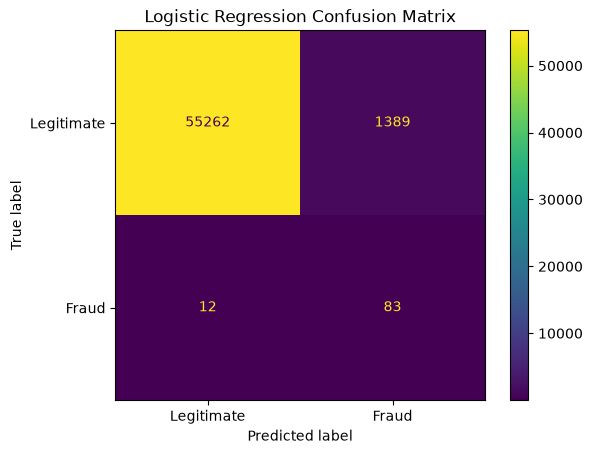

In [36]:
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
).plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

## Logistic Regression Confusion Matrix

The confusion matrix shows that the Logistic Regression model correctly
identified 83 fraudulent transactions and missed 12 fraudulent transactions.

However, 1,389 legitimate transactions were incorrectly classified as
fraudulent.

The model therefore achieves high fraud recall but relatively low precision.
This indicates that the baseline model is effective at detecting many fraud
cases but produces a large number of false positive alerts.

This trade-off motivates the evaluation of additional machine learning
models.

In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

decision_tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=6,
        class_weight="balanced",
        random_state=42
    ))
])

In [38]:
decision_tree_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['Time','V1','V2',...,'V27','V28','Amount']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified i

In [39]:
dt_pred = decision_tree_pipeline.predict(X_test)
dt_prob = decision_tree_pipeline.predict_proba(X_test)[:, 1]

In [40]:
print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall   :", recall_score(y_test, dt_pred))
print("F1 Score :", f1_score(y_test, dt_pred))
print("ROC-AUC  :", roc_auc_score(y_test, dt_prob))
print("PR-AUC   :", average_precision_score(y_test, dt_prob))

Accuracy : 0.9807211080957248
Precision: 0.0682800345721694
Recall   : 0.8315789473684211
F1 Score : 0.12619808306709265
ROC-AUC  : 0.9148448162293787
PR-AUC   : 0.4695769173991331


## Model 2: Decision Tree

A Decision Tree classifier with a maximum depth of 6 and balanced class
weights was evaluated against the Logistic Regression baseline.

The Decision Tree achieved an accuracy of 98.07%, precision of 6.83%,
recall of 83.16%, F1-score of 12.62%, ROC-AUC of 91.48% and PR-AUC of
46.96%.

Although the Decision Tree achieved slightly higher accuracy, precision and
F1-score than Logistic Regression, its recall and PR-AUC were lower.

Because fraud detection involves severe class imbalance, PR-AUC and recall
are particularly important. Therefore, the Decision Tree does not clearly
outperform the Logistic Regression baseline.

In [41]:
from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

In [42]:
random_forest_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['Time','V1','V2',...,'V27','V28','Amount']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified i

In [43]:
rf_pred = random_forest_pipeline.predict(X_test)
rf_prob = random_forest_pipeline.predict_proba(X_test)[:, 1]

In [44]:
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_prob))
print("PR-AUC   :", average_precision_score(y_test, rf_prob))

Accuracy : 0.9992422373383146
Precision: 0.776595744680851
Recall   : 0.7684210526315789
F1 Score : 0.7724867724867724
ROC-AUC  : 0.9745970944908299
PR-AUC   : 0.7822183325813765


from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

print(random_forest_pipeline)

In [45]:
random_forest_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['Time','V1','V2',...,'V27','V28','Amount']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified i

In [46]:
rf_pred = random_forest_pipeline.predict(X_test)
rf_prob = random_forest_pipeline.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [47]:
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_prob))
print("PR-AUC   :", average_precision_score(y_test, rf_prob))

Accuracy : 0.9992422373383146
Precision: 0.776595744680851
Recall   : 0.7684210526315789
F1 Score : 0.7724867724867724
ROC-AUC  : 0.9745970944908299
PR-AUC   : 0.7822183325813765


## Model 3: Random Forest

A Random Forest classifier with 100 trees, a maximum depth of 10 and
balanced class weights was trained and evaluated.

The model achieved:

- Accuracy: 99.92%
- Precision: 77.66%
- Recall: 76.84%
- F1 Score: 77.25%
- ROC-AUC: 97.46%
- PR-AUC: 78.22%

Random Forest substantially outperformed both Logistic Regression and the
single Decision Tree, particularly in precision, F1-score and PR-AUC.

The model provides a much better balance between detecting fraudulent
transactions and limiting false positive alerts.

However, approximately 23% of fraudulent transactions are still missed at
the default classification threshold. Therefore, threshold analysis will be
performed to investigate different precision-recall trade-offs.

dresults = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, dt_prob),
        roc_auc_score(y_test, rf_prob)
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_prob),
        average_precision_score(y_test, dt_prob),
        average_precision_score(y_test, rf_prob)
    ]
})

results

In [48]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, dt_prob),
        roc_auc_score(y_test, rf_prob)
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_prob),
        average_precision_score(y_test, dt_prob),
        average_precision_score(y_test, rf_prob)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.975311,0.056386,0.873684,0.105935,0.965655,0.671924
1,Decision Tree,0.980721,0.068280,0.831579,0.126198,0.914845,0.469577
2,Random Forest,0.999242,0.776596,0.768421,0.772487,0.974597,0.782218


## Model Comparison Conclusion

Random Forest is currently the strongest overall model among the three
evaluated classifiers.

It achieves the highest accuracy, precision, F1-score, ROC-AUC and PR-AUC,
while maintaining a recall of 76.84%.

Logistic Regression achieves the highest recall of 87.37%, but its precision
is only 5.64%, resulting in many false positive alerts.

Therefore, Random Forest provides a better overall balance between detecting
fraud and reducing false positive predictions.

The next step is to investigate different classification thresholds to
determine whether the Random Forest model can achieve a more suitable
precision-recall trade-off.

In [49]:
import matplotlib.pyplot as plt

[[56630    21]
 [   22    73]]


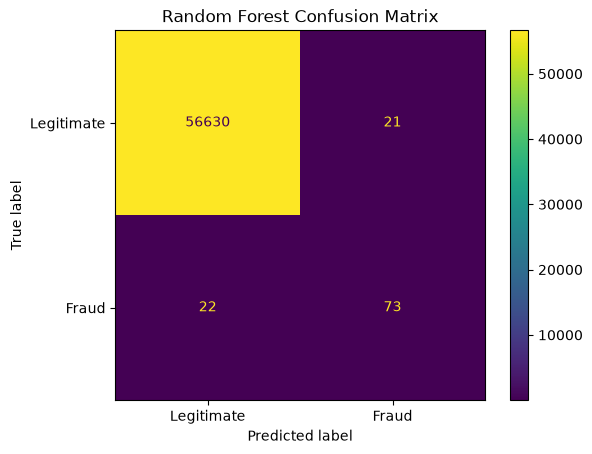

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

rf_cm = confusion_matrix(y_test, rf_pred)

print(rf_cm)

ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["Legitimate", "Fraud"]
).plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

In [51]:
tn, fp, fn, tp = rf_cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 56630
False Positives: 21
False Negatives: 22
True Positives : 73


## Random Forest Confusion Matrix

The Random Forest confusion matrix shows:

- True Negatives: 56,630
- False Positives: 21
- False Negatives: 22
- True Positives: 73

The model correctly identifies 73 fraudulent transactions while producing
only 21 false positive alerts.

Compared with Logistic Regression, which produced 1,389 false positives,
Random Forest dramatically reduces unnecessary fraud alerts.

However, Random Forest misses 22 fraudulent transactions compared with only
12 missed by Logistic Regression. This demonstrates the precision-recall
trade-off that will be investigated through classification threshold tuning.

In [52]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:
    predictions = (rf_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1 Score": f1_score(y_test, predictions, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1 Score
0,0.10,0.061794,0.863158,0.115331
1,0.15,0.141093,0.842105,0.241692
2,0.20,0.259740,0.842105,0.397022
3,0.25,0.379808,0.831579,0.521452
4,0.30,0.478261,0.810526,0.601562
5,0.35,0.596899,0.810526,0.687500
6,0.40,0.663717,0.789474,0.721154
7,0.45,0.742574,0.789474,0.765306
8,0.50,0.776596,0.768421,0.772487
9,0.55,0.818182,0.757895,0.786885


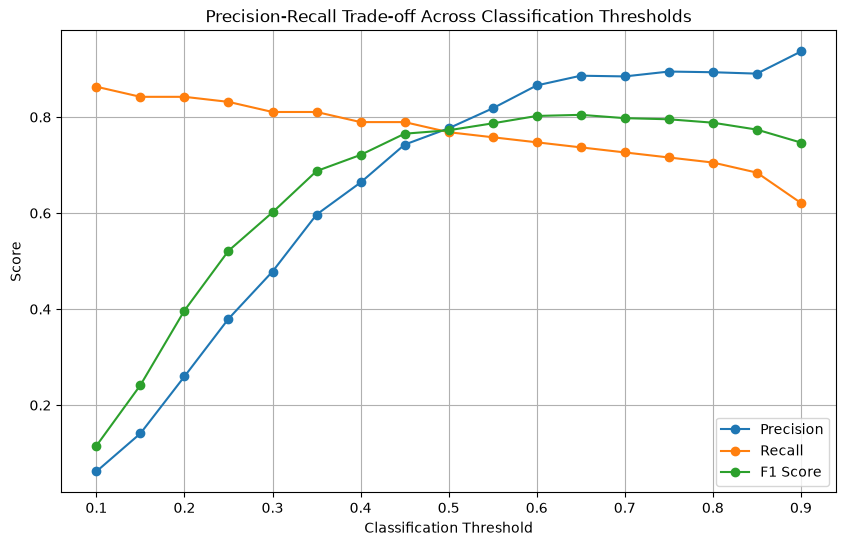

In [53]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Trade-off Across Classification Thresholds")
plt.legend()
plt.grid(True)

plt.show()

In [54]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1 Score"].idxmax()
]

best_threshold_row

Threshold    0.650000
Precision    0.886076
Recall       0.736842
F1 Score     0.804598
Name: 11, dtype: float64

In [55]:
print("Best threshold:", best_threshold_row["Threshold"])
print("Precision:", best_threshold_row["Precision"])
print("Recall:", best_threshold_row["Recall"])
print("F1 Score:", best_threshold_row["F1 Score"])

Best threshold: 0.6500000000000001
Precision: 0.8860759493670886
Recall: 0.7368421052631579
F1 Score: 0.8045977011494253


## Classification Threshold Analysis

The Random Forest model was evaluated across classification thresholds from
0.10 to 0.90.

Increasing the classification threshold increases precision but generally
reduces recall. This demonstrates the trade-off between reducing false
positive alerts and detecting a larger proportion of fraudulent transactions.

The optimal threshold for the current analysis is selected based on the
highest F1-score, providing a balance between precision and recall.

This threshold will be used as the selected operating point for the FraudLens
baseline deployment model.

## Selected Classification Threshold

The Random Forest model was evaluated across classification thresholds from
0.10 to 0.90 in increments of 0.05.

Among the tested thresholds, 0.65 produced the highest F1-score.

At this threshold:

- Precision: 88.61%
- Recall: 73.68%
- F1 Score: 80.46%

Compared with the default threshold of 0.50, the selected threshold improves
precision from 77.66% to 88.61% while reducing recall from 76.84% to 73.68%.

This represents a useful trade-off for FraudLens because the higher threshold
substantially reduces false positive alerts while retaining the ability to
detect a large proportion of fraudulent transactions.